# Epigenomic Data Analysis: ChIP-seq Peak Calling with MACS3

Install required packages

In [1]:
# Install MACS3 and samtools for basic QC

!pip install MACS3

# samtools is needed for flagstat (read statistics)

!apt-get update && apt-get install -y samtools

print("Packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 713.8/713.8 kB 9.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached hmmlearn-0.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.0 kB)
  Using cached cykhash-2.0.1-cp312-cp312-linux_x86_64.whl
Using cached hmmlearn-0.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (165 kB)
  Created wheel for MACS3: filename=macs3-3.0.4-cp312-cp312-linux_x86_64.whl size=3751636 sha256=127a913d4f713d296728d9e951e4db262b8a786995615b181b99eaf032813ac4
  Stored in directory: /root/.cache/pip/wheels/6f/ce/a8/4fcced6c4349d1827cbbe7a11cba717f8279c5cdaf4c332713
Successfully built MACS3
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4

Download the data

In [2]:
# Download treatment (ChIP) and control (Input) BAM files + indices

!wget https://raw.githubusercontent.com/macs3-project/MACS/main/test/CTCF_PE_ChIP_chr22_50k.bam -O CTCF_ChIP.bam

!wget https://raw.githubusercontent.com/macs3-project/MACS/main/test/CTCF_PE_CTRL_chr22_50k.bam -O Input.bam

# Download indices (optional but good practice)

!wget https://raw.githubusercontent.com/macs3-project/MACS/main/test/CTCF_PE_ChIP_chr22_50k.bam.bai -O CTCF_ChIP.bam.bai

!wget https://raw.githubusercontent.com/macs3-project/MACS/main/test/CTCF_PE_CTRL_chr22_50k.bam.bai -O Input.bam.bai

print("✅ Real dataset downloaded!")

!ls -lh *.bam

--2026-07-02 07:10:31--  https://raw.githubusercontent.com/macs3-project/MACS/main/test/CTCF_PE_ChIP_chr22_50k.bam
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9490466 (9.1M) [application/octet-stream]
Saving to: ‘CTCF_ChIP.bam’

CTCF_ChIP.bam       100%[===================>]   9.05M  --.-KB/s    in 0.07s   

2026-07-02 07:10:31 (138 MB/s) - ‘CTCF_ChIP.bam’ saved [9490466/9490466]

--2026-07-02 07:10:31--  https://raw.githubusercontent.com/macs3-project/MACS/main/test/CTCF_PE_CTRL_chr22_50k.bam
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 

Basic Quality Control with samtools

In [3]:
# Simple QC: number of reads, mapping rate, etc.

print("=== ChIP sample QC ===")

!samtools flagstat CTCF_ChIP.bam

print("\n=== Input control QC ===")

!samtools flagstat Input.bam

=== ChIP sample QC ===
99335 + 0 in total (QC-passed reads + QC-failed reads)
99335 + 0 primary
0 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
99335 + 0 mapped (100.00% : N/A)
99335 + 0 primary mapped (100.00% : N/A)
99335 + 0 paired in sequencing
49728 + 0 read1
49607 + 0 read2
99209 + 0 properly paired (99.87% : N/A)
99243 + 0 with itself and mate mapped
92 + 0 singletons (0.09% : N/A)
20 + 0 with mate mapped to a different chr
20 + 0 with mate mapped to a different chr (mapQ>=5)

=== Input control QC ===
101939 + 0 in total (QC-passed reads + QC-failed reads)
101939 + 0 primary
0 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
101939 + 0 mapped (100.00% : N/A)
101939 + 0 primary mapped (100.00% : N/A)
101939 + 0 paired in sequencing
51080 + 0 read1
50859 + 0 read2
101572 + 0 properly paired (99.64% : N/A)
101804 + 0 with itself and mate mapped
135 + 0 singletons (0.13% : N/A)
193 + 0 with mate mapped to a different chr
193 +

Run MACS3 peak calling

In [4]:
import os

os.makedirs("results", exist_ok=True)

# Run MACS3 peak calling

!macs3 callpeak \
-t CTCF_ChIP.bam \
-c Input.bam \
-f BAMPE \
-g hs \
--name CTCF_Demo \
--outdir results \
--qvalue 0.01 \
--keep-dup all

print("✅ Peak calling completed! Check the results folder.")

!ls results/

INFO  @ 02 Jul 2026 07:18:34: [111 MB] 
# Command line: callpeak -t CTCF_ChIP.bam -c Input.bam -f BAMPE -g hs --name CTCF_Demo --outdir results --qvalue 0.01 --keep-dup all
# ARGUMENTS LIST:
# name = CTCF_Demo
# format = BAMPE
# ChIP-seq file = ['CTCF_ChIP.bam']
# control file = ['Input.bam']
# effective genome size = 2.91e+09
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 1.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 1000 bps and 10000 bps
# Broad region calling is off
# Paired-End mode is on
 
INFO  @ 02 Jul 2026 07:18:34: [111 MB] #1 read fragment files... 
INFO  @ 02 Jul 2026 07:18:34: [111 MB] #1 read treatment fragments... 
INFO  @ 02 Jul 2026 07:18:35: [111 MB] 49622 fragments have been read. 
INFO  @ 02 Jul 2026 07:18:35: [111 MB] #1.2 read

Explore the output peaks with pandas + visualization

Number of significant peaks called: 677
     chr     start       end              name  score strand  signalValue  \
0  chr22  16058731  16059061  CTCF_Demo_peak_1     27      .       1.9914   
1  chr22  17255466  17255848  CTCF_Demo_peak_2    238      .      14.1908   
2  chr22  17372662  17373263  CTCF_Demo_peak_3    540      .      25.8070   
3  chr22  17392205  17392708  CTCF_Demo_peak_4    746      .      32.9290   
4  chr22  17398270  17398739  CTCF_Demo_peak_5    586      .      24.2903   

     pValue    qValue  peak  
0   5.03162   2.79649   165  
1  26.59030  23.86270   173  
2  57.31710  54.05980   285  
3  78.25700  74.62510   238  
4  62.01340  58.67220   199  

Average peak length: 455 bp


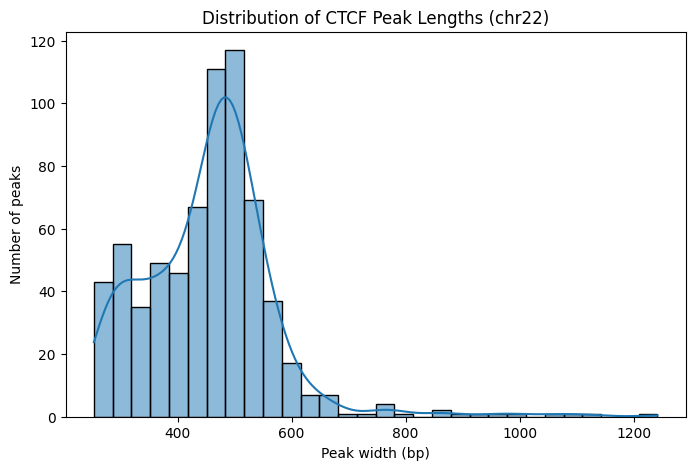


Top 5 strongest peaks:
       chr     start       end  signalValue   qValue
185  chr22  24298649  24299198      75.6412  200.172
396  chr22  36461840  36462611      60.2044  160.904
415  chr22  37252275  37252935      59.2496  224.294
70   chr22  20918442  20919129      59.2177  149.898
97   chr22  22292300  22293386      58.6915  163.090


In [5]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

# Load the narrowPeak file (standard 10-column format)

peaks = pd.read_csv("results/CTCF_Demo_peaks.narrowPeak",

sep="\t",

header=None,

names=["chr", "start", "end", "name", "score",

"strand", "signalValue", "pValue", "qValue", "peak"])

print(f"Number of significant peaks called: {len(peaks)}")

print(peaks.head())

# Basic statistics & plots

peaks["length"] = peaks["end"] - peaks["start"]

print(f"\nAverage peak length: {peaks['length'].mean():.0f} bp")

plt.figure(figsize=(8, 5))

sns.histplot(peaks["length"], bins=30, kde=True)

plt.title("Distribution of CTCF Peak Lengths (chr22)")

plt.xlabel("Peak width (bp)")

plt.ylabel("Number of peaks")

plt.show()

# Simple summary table

print("\nTop 5 strongest peaks:")

print(peaks.nlargest(5, "signalValue")[["chr", "start", "end", "signalValue", "qValue"]])